## Anomaly Detection for IDS

This notebook demonstrates an anomaly detection workflow for intrusion detection using the Mirai Botnet network traffic dataset. It loads packet-level network traffic data, prepares different feature representations, and trains machine learning models to distinguish benign traffic from malicious botnet activity.

The notebook compares multiple ways of representing network traffic, including raw packet features, statistical aggregates, and flow-based features. These representations are then used to evaluate how different feature construction strategies affect IDS classification performance.

# Environment

This script requires Python 3 and the following Python packages:

```bash
pip install pandas numpy tensorflow scikit-learn matplotlib seaborn

# Dataset

- Dataset: Mirai Botnet Network Traffic Data (source: https://arxiv.org/abs/1802.09089)
    - dataset as per demo: (https://drive.google.com/drive/folders/1-PhVWTAJ555nAWtbR2an47hfnUnRp0EJ?usp=sharing)
- Raw data comes in pcap format. We extract features using Wireshark (see the feature_extraction.py script)
- NOTE: To run the code in this notebook on your own, ensure that you have downloaded the necessary data files and placed them in the appropriate folder structure. If you prefer to store the data files in a different location, make sure to update the file paths in the code accordingly to point to the correct data location.

In [3]:
import pandas as pd
import numpy as np

In [4]:
raw_dataset = pd.read_csv('data/mirai_botnet/mirai_pcap.tsv', sep='\t')
raw_dataset

,frame.time_epoch,frame.len,eth.src,eth.dst,eth.type,ip.src,ip.dst,ip.proto,ip.ttl,ip.version,...,udp.srcport,udp.dstport,udp.length,icmp.type,icmp.code,arp.opcode,arp.src.hw_mac,arp.src.proto_ipv4,arp.dst.hw_mac,arp.dst.proto_ipv4
0,1.540446e+09,60,5c:cf:7f:05:f2:c6,4c:09:d4:c6:12:7b,0x0800,192.168.2.108,52.24.43.67,6.0,255.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.540446e+09,60,5c:cf:7f:05:f2:c6,4c:09:d4:c6:12:7b,0x0800,192.168.2.108,52.25.66.250,6.0,255.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.540446e+09,86,4c:09:d4:c6:12:7b,5c:cf:7f:05:f2:c6,0x0800,192.168.2.1,192.168.2.108,1.0,64.0,4.0,...,NaN,NaN,NaN,3.0,0.0,NaN,NaN,NaN,NaN,NaN
3,1.540446e+09,86,4c:09:d4:c6:12:7b,5c:cf:7f:05:f2:c6,0x0800,192.168.2.1,192.168.2.108,1.0,64.0,4.0,...,NaN,NaN,NaN,3.0,0.0,NaN,NaN,NaN,NaN,NaN
4,1.540446e+09,60,48:02:2e:01:83:15,ff:ff:ff:ff:ff:ff,0x0806,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,48:02:2e:01:83:15,192.168.2.109,00:00:00:00:00:00,192.168.2.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764132,1.540454e+09,60,3c:33:00:98:ee:fd,ff:ff:ff:ff:ff:ff,0x0806,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,3c:33:00:98:ee:fd,192.168.2.110,00:00:00:00:00:00,192.168.2.165
764133,1.540454e+09,60,3c:33:00:98:ee:fd,ff:ff:ff:ff:ff:ff,0x0806,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,3c:33:00:98:ee:fd,192.168.2.110,00:00:00:00:00:00,192.168.2.166
764134,1.540454e+09,60,3c:33:00:98:ee:fd,ff:ff:ff:ff:ff:ff,0x0806,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,3c:33:00:98:ee:fd,192.168.2.110,00:00:00:00:00:00,192.168.2.167
764135,1.540454e+09,60,3c:33:00:98:ee:fd,ff:ff:ff:ff:ff:ff,0x0806,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,3c:33:00:98:ee:fd,192.168.2.110,00:00:00:00:00:00,192.168.2.168


In [5]:
raw_dataset.columns

Index(['frame.time_epoch', 'frame.len', 'eth.src', 'eth.dst', 'eth.type',
       'ip.src', 'ip.dst', 'ip.proto', 'ip.ttl', 'ip.version', 'ip.flags',
       'ip.id', 'ip.len', 'ipv6.src', 'ipv6.dst', 'tcp.srcport', 'tcp.dstport',
       'tcp.flags.str', 'tcp.seq', 'tcp.len', 'tcp.window_size', 'udp.srcport',
       'udp.dstport', 'udp.length', 'icmp.type', 'icmp.code', 'arp.opcode',
       'arp.src.hw_mac', 'arp.src.proto_ipv4', 'arp.dst.hw_mac',
       'arp.dst.proto_ipv4'],
      dtype='object')

# Feature Representations

There are several different ways we can transform and represent our network traffic data for machine learning:

- Using the raw packet data as is and giving the raw packets directly to the machine learning model.
- Preparing aggregations of the packet data:
  - Converting packets into network traffic flows, which describe the end-to-end communication between source and destination.
  - Segmenting packets into fixed-size flow "windows", e.g. considering all the packets in every 1 second interval. From these flow windows, we can extract statistical features and aggregates (mean, median, variance, etc.) to represent the traffic patterns
- We'll experiment with 3 different feature representations:
  - using just the raw packets (Packets)
  - using a stats-based aggregate of the packets (Stats)
  - using end-to-end communication flows (Flows)

# Load Preprocessed Data

## Packets

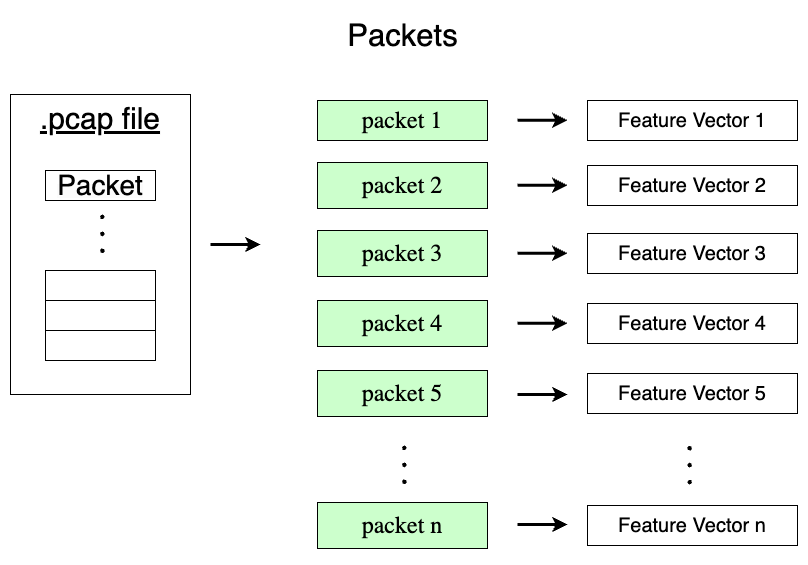

In [6]:
packets_dataset = pd.read_csv('data/mirai_botnet/mirai_pcap_preprocessed.csv')
packets_dataset

,frame.len,ip.ttl,ip.len,tcp.srcport,tcp.dstport,tcp.seq,tcp.len,tcp.window_size,udp.srcport,udp.dstport,...,tcp.flags.str_·······A···F,tcp.flags.str_·······A····,tcp.flags.str_·········R··,tcp.flags.str_··········S·,icmp.type_0.0,icmp.type_3.0,icmp.type_8.0,icmp.code_0.0,arp.opcode_1.0,arp.opcode_2.0
0,60,255.0,44.0,21074.0,80.0,0.0,0.0,5840.0,0.0,0.0,...,False,False,False,True,False,False,False,False,False,False
1,60,255.0,44.0,20532.0,8280.0,0.0,0.0,5840.0,0.0,0.0,...,False,False,False,True,False,False,False,False,False,False
2,86,64.0,72.0,21074.0,80.0,33948381.0,0.0,5840.0,0.0,0.0,...,False,False,False,True,False,True,False,True,False,False
3,86,64.0,72.0,20532.0,8280.0,30023305.0,0.0,5840.0,0.0,0.0,...,False,False,False,True,False,True,False,True,False,False
4,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764132,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
764133,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
764134,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
764135,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False


## Flows

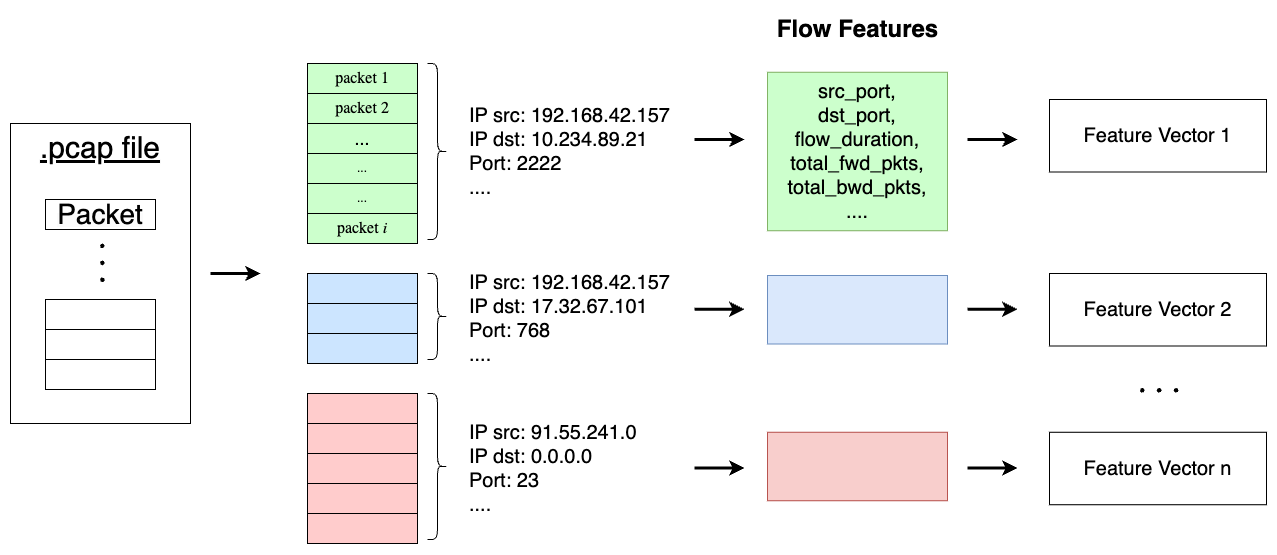

In [7]:
flows_dataset = pd.read_csv('data/mirai_botnet/mirai_flows_preprocessed.csv')
flows_dataset

,src_port,dst_port,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,...,fwd_seg_size_avg,bwd_seg_size_avg,cwe_flag_count,subflow_fwd_pkts,subflow_bwd_pkts,subflow_fwd_byts,subflow_bwd_byts,label,protocol_6,protocol_17
0,21074,80,1027785.0,175.133904,2.918898,2.918898,0.000000,3,0,180,...,60.0,0.0,0,3,0,180,0,0.0,True,False
1,20532,8280,1027855.0,175.121977,2.918700,2.918700,0.000000,3,0,180,...,60.0,0.0,0,3,0,180,0,0.0,True,False
2,2440,53,5048656.0,79.625152,0.792290,0.594218,0.198073,3,1,285,...,95.0,117.0,0,3,1,285,117,0.0,False,True
3,52514,53,0.0,0.000000,0.000000,0.000000,0.000000,1,0,76,...,76.0,0.0,0,1,0,76,0,0.0,False,True
4,34034,53,0.0,0.000000,0.000000,0.000000,0.000000,1,0,83,...,83.0,0.0,0,1,0,83,0,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36128,3568,53,2422.0,96614.368291,825.763832,412.881916,412.881916,1,1,117,...,117.0,117.0,0,1,1,117,117,1.0,False,True
36129,3569,53,0.0,0.000000,0.000000,0.000000,0.000000,1,0,84,...,84.0,0.0,0,1,0,84,0,1.0,False,True
36130,59322,53,0.0,0.000000,0.000000,0.000000,0.000000,1,0,83,...,83.0,0.0,0,1,0,83,0,1.0,False,True
36131,35284,53,0.0,0.000000,0.000000,0.000000,0.000000,1,0,76,...,76.0,0.0,0,1,0,76,0,1.0,False,True


## Stats

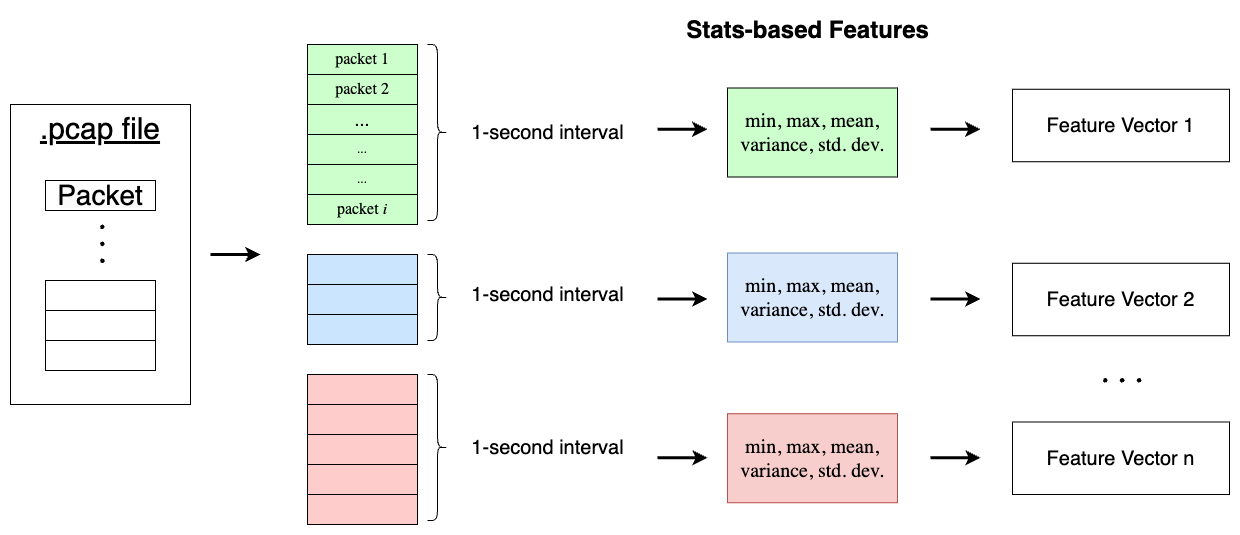

In [8]:
stats_dataset = pd.read_csv('data/mirai_botnet/mirai_stats_preprocessed.csv')
stats_dataset

,frame.len_min,ip.proto_min,ip.ttl_min,ip.len_min,tcp.srcport_min,tcp.dstport_min,tcp.seq_min,tcp.len_min,tcp.window_size_min,udp.srcport_min,...,tcp.flags.str_·······A····_var,tcp.flags.str_·········R··_var,tcp.flags.str_··········S·_var,icmp.type_0.0_var,icmp.type_3.0_var,icmp.type_8.0_var,icmp.code_0.0_var,arp.opcode_1.0_var,arp.opcode_2.0_var,label
0,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.164706,0.028571,0.210084,0.028571,0.231933,0.028571,0.000000,0
1,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.117354,0.026316,0.051209,0.026316,0.096728,0.051209,0.026316,0
2,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.105205,0.023256,0.086379,0.023256,0.122924,0.023256,0.000000,0
3,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.217508,0.018182,0.139394,0.018182,0.162963,0.018182,0.000000,0
4,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.079556,0.041628,0.097132,0.041628,0.158187,0.021277,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7132,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.019835,0.004032,0.008032,0.004032,0.015933,0.087763,0.000000,1
7133,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.005181,0.054026,0.005181,0.020402,0.005181,0.030278,0.179728,0.000000,1
7134,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.004762,0.000000,0.009478,0.018774,0.009478,0.036819,0.112577,0.000000,1
7135,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.023335,0.003968,0.007905,0.003968,0.015683,0.056204,0.000000,1


# Run Deep Learning Model

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import losses
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import auc, roc_curve, confusion_matrix, precision_recall_fscore_support

## Autoencoder Model

* This neural network architecture tries to learn the important features of your data by using a reconstruction-based learning process.
* The idea is that the model compresses (encode) the input down to a much smaller representation at the latent layer, then decompresses (decode) it to its original dimensions at the output layer.
* The goal is to essentially reconstruct the original image; for the model to successfully do this, the latent layer must have learnt the important characteristics of the input data.
* The ability of the model to perform this reconstruction is characterised by the **reconstruction error**, which is just a number that measures how close the reconstruction is to its input - a low reconstruction error means a good reconstruction, while a high error means a poor reconstruction.

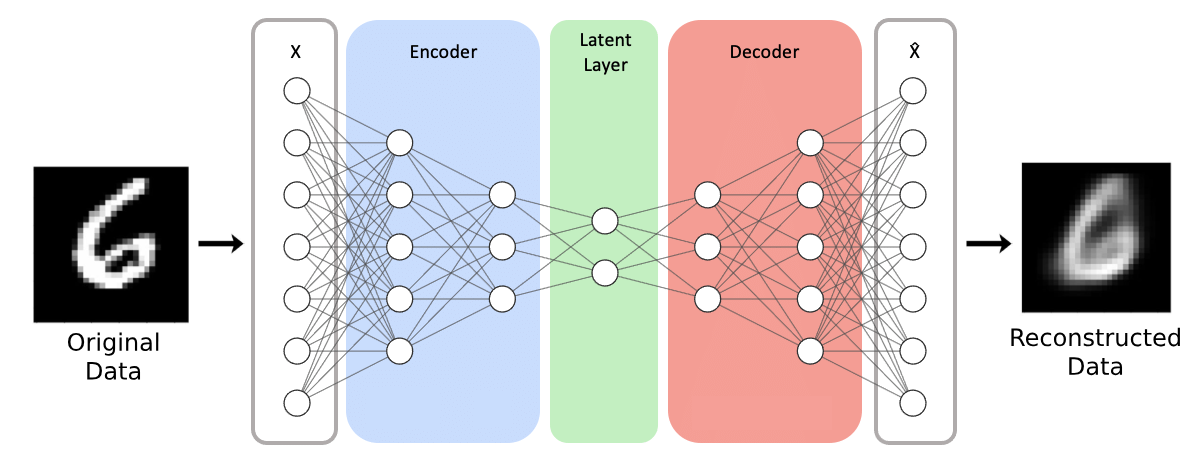

## How autoencoders are used in anomaly-based IDS:

1. Train the autoencoder on **only the normal network traffic data** (without any intrusions)
2. Afterwhich, the model should have learnt a good representation for your data; i.e. the model should be able to "reconstruct" normal network traffic data. Thus, the model should **NOT** be able to adequately reconstruct malicious network traffic data.
3. We deploy this model as an IDS: if the model sees normal activity, then the reconstruction error for that activity should be low. If the model sees malicious activity, the reconstruction error should be high, and we can thus flag for intrusions.

In [10]:
class Autoencoder(Model):
    def __init__(self, latent_dim, input_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.encoder = tf.keras.Sequential([ # encoder (compressor) part of the model
            Dense(self.input_dim, activation='relu'),
            Dense(self.latent_dim, activation='relu'), # latent layer
        ])
        self.decoder = tf.keras.Sequential([ # decoder (decompressor) part of the model
            Dense(self.latent_dim, activation='relu'),
            Dense(self.input_dim, activation='sigmoid')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [11]:
def split_data(df):
    ''' separate normal and malicious data into our training and testing datasets '''
    X_train = df[df['label'] == 0]
    X_test = df[df['label'] == 1]
    y_train = X_train.pop('label')
    y_test = X_test.pop('label')

    X_train = X_train.astype(np.float32).to_numpy()
    X_test = X_test.astype(np.float32).to_numpy()
    return X_train, X_test, y_train, y_test

def scale_data(X_train, X_test):
    ''' scale the data using StandardScaler, which standardizes features by removing the mean and scaling to unit variance. '''
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test

In [12]:
def get_losses(model, X_train, X_test):
    ''' get the reconstruction losses (errors) for the training and testing datasets '''
    train_rec = model.predict(X_train, verbose=0)
    test_rec  = model.predict(X_test,  verbose=0)

    mse = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.NONE)

    train_losses = mse(X_train, train_rec).numpy()
    test_losses  = mse(X_test,  test_rec).numpy()

    return train_losses, test_losses


def get_metrics(train_losses, test_losses):
    ''' calculate ML metrics: accuracy, precision, recall, f1_score '''
    values_to_threshold = test_losses.tolist() + train_losses.tolist()
    labels_to_threshold = [1] * len(test_losses) + [0] * len(train_losses)

    fpr, tpr, thresholds = roc_curve(labels_to_threshold, values_to_threshold)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    predicted = [1 if value > optimal_threshold else 0 for value in values_to_threshold] # 1 = attack
    cm = confusion_matrix(labels_to_threshold, predicted)

    accuracy = accuracy_score(labels_to_threshold, predicted)
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels_to_threshold, predicted, average='binary')

    return accuracy, precision, recall, f1_score

In [13]:
def run_ml_pipeline(dataset):
  x_train, x_test, _, _ = split_data(dataset)
  X_train, X_test = scale_data(x_train, x_test)

  input_dim = X_train[0].shape[0]
  latent_dim = 32

  autoencoder = Autoencoder(latent_dim, input_dim)
  autoencoder.compile(optimizer="adam", loss=losses.MeanSquaredError())
  early_stopping = EarlyStopping(monitor='loss', patience=15, mode='min', min_delta=0.0001)
  autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, shuffle=False, callbacks=[early_stopping])
  train_losses, test_losses = get_losses(autoencoder, X_train, X_test)
  return get_metrics(train_losses, test_losses)

In [14]:
print('--- PACKETS --- ')
packets_metrics = run_ml_pipeline(packets_dataset)

accuracy, precision, recall, f1_score = packets_metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'F1 Score: {f1_score * 100:.2f}%')

--- PACKETS --- 


2026-05-16 21:06:19.018414: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-16 21:06:19.018440: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-16 21:06:19.018453: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-16 21:06:19.018495: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-16 21:06:19.018527: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10
   1/1901 [..............................] - ETA: 13:06 - loss: 0.8597

2026-05-16 21:06:19.528013: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1901/1901 [==============================] - 7s 3ms/step - loss: 0.9143
Epoch 2/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.0779
Epoch 3/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.1821
Epoch 4/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.2007
Epoch 5/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.2189
Epoch 6/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.2150
Epoch 7/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.2176
Epoch 8/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.2290
Epoch 9/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.2871
Epoch 10/10
1901/1901 [==============================] - 6s 3ms/step - loss: 1.3721
Accuracy: 88.78%
Recall: 87.95%
Precision: 98.56%
F1 Score: 92.95%


In [15]:
print('--- FLOWS --- ')
flows_metrics = run_ml_pipeline(flows_dataset)

accuracy, precision, recall, f1_score = flows_metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'F1 Score: {f1_score * 100:.2f}%')

--- FLOWS --- 
Epoch 1/10
349/349 [==============================] - 2s 4ms/step - loss: 0.7245
Epoch 2/10
349/349 [==============================] - 1s 3ms/step - loss: 0.7177
Epoch 3/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8060
Epoch 4/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8255
Epoch 5/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8516
Epoch 6/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8545
Epoch 7/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8545
Epoch 8/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8546
Epoch 9/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8546
Epoch 10/10
349/349 [==============================] - 1s 3ms/step - loss: 0.8545
Accuracy: 60.64%
Recall: 13.21%
Precision: 45.44%
F1 Score: 20.47%


In [16]:
print('--- STATS --- ')
stats_metrics = run_ml_pipeline(stats_dataset)

accuracy, precision, recall, f1_score = stats_metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'F1 Score: {f1_score * 100:.2f}%')

--- STATS --- 
Epoch 1/10
70/70 [==============================] - 1s 4ms/step - loss: 0.7673
Epoch 2/10
70/70 [==============================] - 0s 3ms/step - loss: 0.6505
Epoch 3/10
70/70 [==============================] - 0s 3ms/step - loss: 0.8034
Epoch 4/10
70/70 [==============================] - 0s 4ms/step - loss: 0.9205
Epoch 5/10
70/70 [==============================] - 0s 3ms/step - loss: 0.9307
Epoch 6/10
70/70 [==============================] - 0s 3ms/step - loss: 0.9580
Epoch 7/10
70/70 [==============================] - 0s 3ms/step - loss: 0.9747
Epoch 8/10
70/70 [==============================] - 0s 3ms/step - loss: 0.9803
Epoch 9/10
70/70 [==============================] - 0s 4ms/step - loss: 0.9735
Epoch 10/10
70/70 [==============================] - 0s 3ms/step - loss: 0.9682
Accuracy: 98.80%
Recall: 96.79%
Precision: 100.00%
F1 Score: 98.37%


# Feature Space Representation

* Do the different encoding methods induce different levels of separability within the data?
* Does a particular representation of the features allow for a greater separation?
* Does the separation correlate with the varied levels of performance, as seen above?

We can check using a t-SNE visualisation
* t-SNE (t-distributed Stochastic Neighbor Embedding) is a non-linear dimensionality reduction technique used to visualize high-dimensional data in 2D or 3D, preserving local structure so that similar points remain close together

In [17]:
# from cuml.manifold import TSNE
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
def regenerate_dataframe(X_train, X_test, y_train, y_test):
    data = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_test)]).reset_index(drop=True)
    labels = pd.concat([pd.DataFrame(y_train), pd.DataFrame(y_test)]).reset_index(drop=True)
    return pd.concat([data, labels], axis=1)

In [19]:
def prep_tsne_data(dataset):
    X_train, X_test, y_train, y_test = split_data(dataset)
    y_train = (y_train == 1).astype(int)
    y_test = (y_test == 1).astype(int)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return regenerate_dataframe(X_train, X_test, y_train, y_test)

In [20]:
def tsne_run(df, dimensions=2):
    ''' run the t-sne model '''
    tsne_full = TSNE(n_components=dimensions, verbose=1, random_state=42)
    X_tsne_full = tsne_full.fit_transform(df.drop('label', axis=1).astype(np.float32).to_numpy())
    return X_tsne_full, df['label'], tsne_full.kl_divergence_

def tsne_remove_outliers(data, labels, use_z_threshold=True, threshold=2):
    ''' remove outliers from the t-sne output, for better visualisation '''
    if use_z_threshold: # threshold is used as z-value
        mean = np.mean(data, axis=0)
        std_dev = np.std(data, axis=0)
        outliers = np.abs(data - mean) > threshold * std_dev
    else: # threshold is used as abolsute
        outliers = np.abs(data) > threshold
    print(f"number of outliers: {np.sum(outliers)}/{len(data)}")
    filtered_data = data[~outliers.any(axis=1)]
    filtered_labels = labels[~outliers.any(axis=1)]
    return filtered_data, filtered_labels

def tsne_plot(data, labels, title):
    ''' plot the t-sne output '''
    df_plot = pd.DataFrame(data, columns=['Dimension 1', 'Dimension 2'])
    df_plot['Label'] = labels
    fig = sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='Label', s=2.5, alpha=0.75, data=df_plot)

    x_min, x_max = df_plot['Dimension 1'].min(), df_plot['Dimension 1'].max()
    y_min, y_max = df_plot['Dimension 2'].min(), df_plot['Dimension 2'].max()

    x_min = x_min - 0.1 * (x_max - x_min)
    x_max = x_max + 0.1 * (x_max - x_min)
    y_min = y_min - 0.1 * (y_max - y_min)
    y_max = y_max + 0.1 * (y_max - y_min)

    fig.set_xlim(x_min, x_max)
    fig.set_ylim(y_min, y_max)

    plt.title(title)
    plt.legend(loc='upper right')
    plt.show()

In [21]:
def run_tsne_pipeline(dataset, dataset_name, threshold=2):
    dataset = prep_tsne_data(dataset)
    X_tsne_full, y_tsne_full, kl_divergence = tsne_run(dataset)
    X_tsne_filtered, y_tsne_filtered = tsne_remove_outliers(
        X_tsne_full,
        y_tsne_full,
        use_z_threshold=True,
        threshold=threshold)
    tsne_plot(X_tsne_filtered, y_tsne_filtered, f't-SNE: {dataset_name}')

In [22]:
packets_dataset_1 = packets_dataset[packets_dataset['label'] == 1]
packets_dataset_0 = packets_dataset[packets_dataset['label'] == 0]
packets_dataset_downsampled = pd.concat([packets_dataset_0,  packets_dataset_1.sample(n=len(packets_dataset_0), random_state=42)])

packets_dataset_downsampled, _ = train_test_split(
    packets_dataset_downsampled,
    train_size=50000,
    stratify=packets_dataset_downsampled['label'],
    random_state=42
)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.006s...
[t-SNE] Computed neighbors for 50000 samples in 1.589s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sam

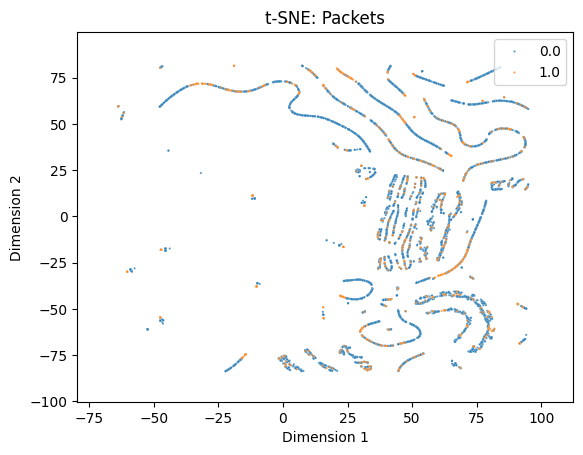

Accuracy: 88.78%
Recall: 87.95%
Precision: 98.56%
F1 Score: 92.95%


In [23]:
run_tsne_pipeline(packets_dataset_downsampled, 'Packets')

accuracy, precision, recall, f1_score = packets_metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'F1 Score: {f1_score * 100:.2f}%')

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 36133 samples in 0.004s...
[t-SNE] Computed neighbors for 36133 samples in 1.444s...
[t-SNE] Computed conditional probabilities for sample 1000 / 36133
[t-SNE] Computed conditional probabilities for sample 2000 / 36133
[t-SNE] Computed conditional probabilities for sample 3000 / 36133
[t-SNE] Computed conditional probabilities for sample 4000 / 36133
[t-SNE] Computed conditional probabilities for sample 5000 / 36133
[t-SNE] Computed conditional probabilities for sample 6000 / 36133
[t-SNE] Computed conditional probabilities for sample 7000 / 36133
[t-SNE] Computed conditional probabilities for sample 8000 / 36133
[t-SNE] Computed conditional probabilities for sample 9000 / 36133
[t-SNE] Computed conditional probabilities for sample 10000 / 36133
[t-SNE] Computed conditional probabilities for sample 11000 / 36133
[t-SNE] Computed conditional probabilities for sample 12000 / 36133
[t-SNE] Computed conditional probabilities for sam

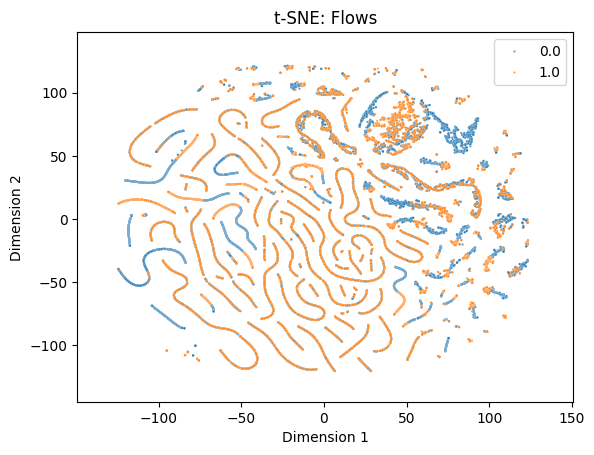

Accuracy: 60.64%
Recall: 13.21%
Precision: 45.44%
F1 Score: 20.47%


In [24]:
run_tsne_pipeline(flows_dataset, 'Flows')

accuracy, precision, recall, f1_score = flows_metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'F1 Score: {f1_score * 100:.2f}%')

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7137 samples in 0.001s...
[t-SNE] Computed neighbors for 7137 samples in 0.235s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7137
[t-SNE] Computed conditional probabilities for sample 2000 / 7137
[t-SNE] Computed conditional probabilities for sample 3000 / 7137
[t-SNE] Computed conditional probabilities for sample 4000 / 7137
[t-SNE] Computed conditional probabilities for sample 5000 / 7137
[t-SNE] Computed conditional probabilities for sample 6000 / 7137
[t-SNE] Computed conditional probabilities for sample 7000 / 7137
[t-SNE] Computed conditional probabilities for sample 7137 / 7137
[t-SNE] Mean sigma: 1.693027
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.177643
[t-SNE] KL divergence after 1000 iterations: 1.016172
number of outliers: 363/7137


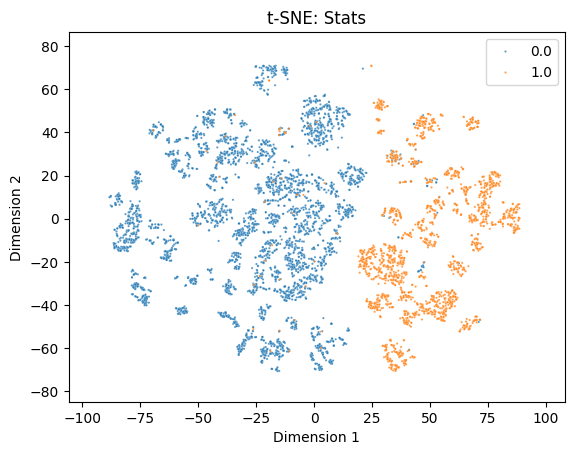

Accuracy: 98.80%
Recall: 96.79%
Precision: 100.00%
F1 Score: 98.37%


In [25]:
run_tsne_pipeline(stats_dataset, 'Stats')

accuracy, precision, recall, f1_score = stats_metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'F1 Score: {f1_score * 100:.2f}%')